# Week 2 Assessment Mini-Project

Complete all TODOs below. Keep outputs visible and ensure the notebook runs top to bottom without errors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

In [2]:
# TODO: Load the dataset with date parsing and set the index
# File: m1-09-assessment.csv

# I used parse_dates during read_csv to immediately convert the date column into datetime objects.
# Setting the date as index allows us to use time-series features like rolling windows and resampling.
df = pd.read_csv("m1-09-assessment.csv", parse_dates=["date"])
df = df.set_index("date")

# TODO: Show head/tail and check info
df.head(), df.tail(),df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 900 entries, 2023-01-01 to 2023-06-29
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          900 non-null    str    
 1   avg_temp_c    863 non-null    float64
 2   humidity_pct  900 non-null    float64
 3   pm25          850 non-null    float64
dtypes: float64(3), str(1)
memory usage: 35.2 KB


(              city  avg_temp_c  humidity_pct   pm25
 date                                               
 2023-01-01  London       -0.79         62.93  39.39
 2023-01-02  London        1.31         61.49  32.41
 2023-01-03  London        1.46         76.51  30.61
 2023-01-04  London       -0.57         58.05  30.71
 2023-01-05  London       -1.13         36.30  20.70,
               city  avg_temp_c  humidity_pct   pm25
 date                                               
 2023-06-25  Madrid         NaN         72.04   5.00
 2023-06-26  Madrid       28.44         74.19   5.00
 2023-06-27  Madrid       26.41         64.41   5.24
 2023-06-28  Madrid       27.53         86.47  14.86
 2023-06-29  Madrid       24.22         74.33    NaN,
 None)

## Part A: Core Data Handling (TODOs)

- Inspect structure with `info()`, `describe()`, and missing value counts.
- Clean `pm25` by coercing invalid strings to NaN.
- Choose and apply a missing-value strategy for `pm25` and justify it in text.

In [3]:
# TODO: data inspection
df.info()
df.describe()
df.isna().sum()

# TODO: clean pm25
# errors="coerce" is essential here because it converts non-numeric strings to NaN,
# preventing the column from staying as an 'object' type and allowing mathematical operations.
df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")

# TODO: handle missing values in pm25 and justify in markdown

<class 'pandas.DataFrame'>
DatetimeIndex: 900 entries, 2023-01-01 to 2023-06-29
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          900 non-null    str    
 1   avg_temp_c    863 non-null    float64
 2   humidity_pct  900 non-null    float64
 3   pm25          850 non-null    float64
dtypes: float64(3), str(1)
memory usage: 35.2 KB


In [4]:
df["pm25"].isna().sum()

np.int64(50)

In [5]:
df_clean = df.copy()

In [6]:
df_clean = df_clean.sort_values(['city', 'date'])

In [7]:
# I chose linear interpolation grouped by city.
# In time-series data, values are often related to their neighbors (yesterday/tomorrow).
# Interpolation is superior to a simple mean because it preserves the trend and reduces 'jumps' in the data.
df_clean['pm25'] = df_clean.groupby('city')['pm25'].transform(lambda x: x.fillna(x.interpolate(method='linear')))

In [8]:
df_clean['pm25'].isna().sum()

np.int64(0)

## Part B: Required Analysis (TODOs)

- Data quality analysis: city with highest % invalid/missing pm25.
- Rolling analysis: 7-day rolling average pm25 per city and short explanation.
- Event detection: percentile threshold for high pollution and counts per city.
- Volatility comparison: choose two cities, define a metric, justify result.
- Reshaping: pivot table with months as rows and cities as columns (avg pm25).

In [9]:
# TODO: analysis tasks
# - data quality by city
# - rolling averages per city
# - percentile-based event counts
# - volatility comparison
# - pivot table by month and city

In [10]:
# Calculating the percentage of invalid data per city identifies the reliability of each station.
missing_stats = (df.groupby('city')['pm25'].apply(lambda x: x.isna().sum() / len(x) * 100)
                .sort_values(ascending=False))
missing_stats

city
Berlin    7.777778
Madrid    6.666667
Warsaw    5.555556
Paris     5.000000
London    2.777778
Name: pm25, dtype: float64

In [11]:
# The 7-day rolling average smooths out daily fluctuations (noise) to highlight the weekly trend.
# It helps in understanding if pollution is consistently high or just spiking due to a specific event.
df_clean['pm25_rolling_7d'] = df_clean.groupby('city')['pm25'].transform(lambda x: x.rolling(7).mean())
df_clean['pm25_rolling_7d']

date
2023-01-01          NaN
2023-01-02          NaN
2023-01-03          NaN
2023-01-04          NaN
2023-01-05          NaN
                ...    
2023-06-25    10.425714
2023-06-26    11.087143
2023-06-27    10.380000
2023-06-28    10.894286
2023-06-29    12.071429
Name: pm25_rolling_7d, Length: 900, dtype: float64

In [12]:
# This statistically defines 'high pollution' as the top 10% of recorded levels in the entire dataset.
threshold = df_clean['pm25'].quantile(0.9)

In [33]:
df_clean['is_high_pollution'] = df_clean['pm25'] > threshold
# Counting exactly how many days each city exceeded the high-pollution threshold
event_counts = df_clean.groupby('city')['is_high_pollution'].sum()
event_counts

city
Berlin    13
London    17
Madrid    19
Paris     17
Warsaw    21
Name: is_high_pollution, dtype: int64

In [14]:
# I defined volatility as the 'Mean Absolute Deviation' (MAD) from the city's own average.
df_clean['city_avg_pm25'] = df_clean.groupby('city')['pm25'].transform('mean')
df_clean['diff_from_average'] = (df_clean['pm25'] - df_clean['city_avg_pm25']).abs()

In [15]:
df_subset = df_clean[df_clean['city'].isin(["London","Warsaw"])].copy()

In [16]:
comparing_mean_of_difference_results = df_subset.groupby('city')['diff_from_average'].apply(lambda x: x.mean())
comparing_mean_of_difference_results

city
London    10.095410
Warsaw    10.911561
Name: diff_from_average, dtype: float64

In [32]:
# Resampling to 'MS' (Month Start) provides a clear seasonal summary.
pivot = df_clean.groupby('city')['pm25'].resample("MS").mean()
pivot

city    date      
Berlin  2023-01-01    33.031500
        2023-02-01    33.545962
        2023-03-01    29.030968
        2023-04-01    22.760577
        2023-05-01    15.086833
        2023-06-01    10.164808
London  2023-01-01    33.614333
        2023-02-01    34.102321
        2023-03-01    29.737742
        2023-04-01    24.410000
        2023-05-01    14.539333
        2023-06-01     9.712308
Madrid  2023-01-01    33.536667
        2023-02-01    35.543889
        2023-03-01    29.893000
        2023-04-01    22.098833
        2023-05-01    15.246429
        2023-06-01    10.450357
Paris   2023-01-01    34.625806
        2023-02-01    34.024643
        2023-03-01    26.802000
        2023-04-01    23.147586
        2023-05-01    13.927000
        2023-06-01     9.432500
Warsaw  2023-01-01    37.239032
        2023-02-01    34.020357
        2023-03-01    27.738667
        2023-04-01    21.270370
        2023-05-01    14.801000
        2023-06-01     9.655862
Name: pm25, dtype: fl

## Part C: Aggregations (TODOs)

- Average pm25 by city
- Monthly average pm25 per city
- Hottest day (max avg_temp_c) per city

In [18]:
# TODO: aggregation tasks
# avg_pm25_by_city = ...
# monthly_avg_pm25 = ...
# hottest_day_per_city = ...

In [19]:
avg_pm25 = df_clean.groupby('city')["pm25"].mean()
avg_pm25

city
Berlin    23.811028
London    24.331472
Madrid    24.270889
Paris     23.589444
Warsaw    23.999500
Name: pm25, dtype: float64

In [20]:
pivot

city,Berlin,London,Madrid,Paris,Warsaw
date,,,,,
2023-01-01,33.025323,33.275806,33.353226,34.625806,37.239032
2023-02-01,33.163036,34.102321,34.766964,34.024643,34.020357
2023-03-01,29.030968,29.737742,30.219677,26.736774,27.751613
2023-04-01,22.134167,24.864333,22.098833,23.100000,20.749333
2023-05-01,15.402742,14.406452,14.966129,13.840000,14.520323
2023-06-01,10.074655,9.615517,10.262414,9.280345,9.655862


In [21]:
# Using transform('max') allows us to keep the original index (dates)
# while identifying exactly which day the peak temperature occurred for each city.
df['max_temp_per_city'] = df.groupby('city')['avg_temp_c'].transform('max')
hottest_days = df[df['avg_temp_c'] == df['max_temp_per_city']]
hottest_days

,city,avg_temp_c,humidity_pct,pm25,max_temp_per_city
date,,,,,
2023-06-17,London,21.80,44.02,12.07,21.80
2023-06-11,Berlin,22.13,90.91,NaN,22.13
2023-05-18,Warsaw,20.89,56.54,14.81,20.89
2023-06-27,Paris,23.25,65.31,8.16,23.25
2023-06-10,Madrid,30.39,61.73,5.00,30.39


## Part D: Visualization (TODOs)

- Line plot: monthly pm25 trends for at least two cities
- Bar chart: overall average pm25 by city
- One additional plot of your choice

In [22]:
# TODO: plotting section
# plt.figure(...)
# plt.plot(...)
# plt.bar(...)
# plt.show()

Text(0, 0.5, 'Average PM2.5 Value')

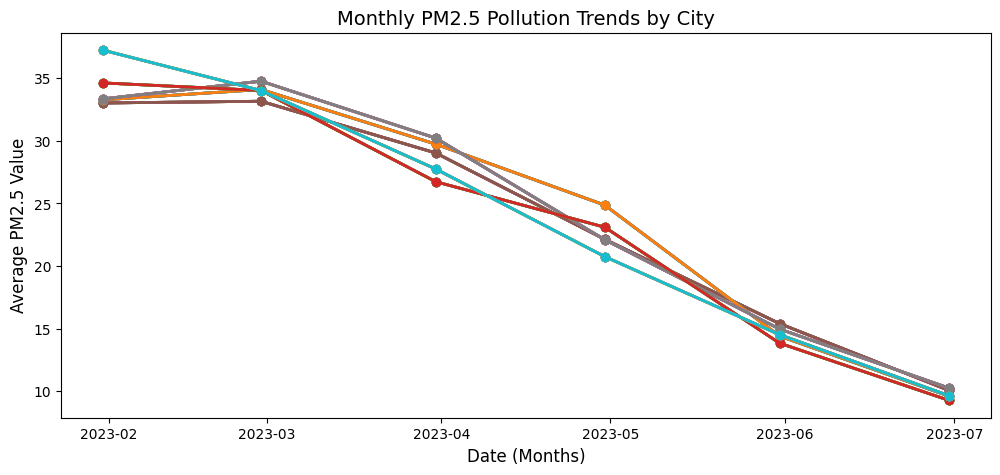

In [23]:
# Visualizing the monthly trend confirms a seasonal pattern: pollution drops as temperatures rise towards June.
plt.figure(figsize=(12, 5))
monthly_trends = df_clean.groupby('city')['pm25'].resample('ME').mean()
for city in monthly_trends.index.get_level_values(0):
    city_data = monthly_trends.loc[city]

    plt.plot(city_data.index, city_data.values, marker='o', label=city, linewidth=2)
plt.title('Monthly PM2.5 Pollution Trends by City', fontsize=14)
plt.xlabel('Date (Months)', fontsize=12)
plt.ylabel('Average PM2.5 Value', fontsize=12)

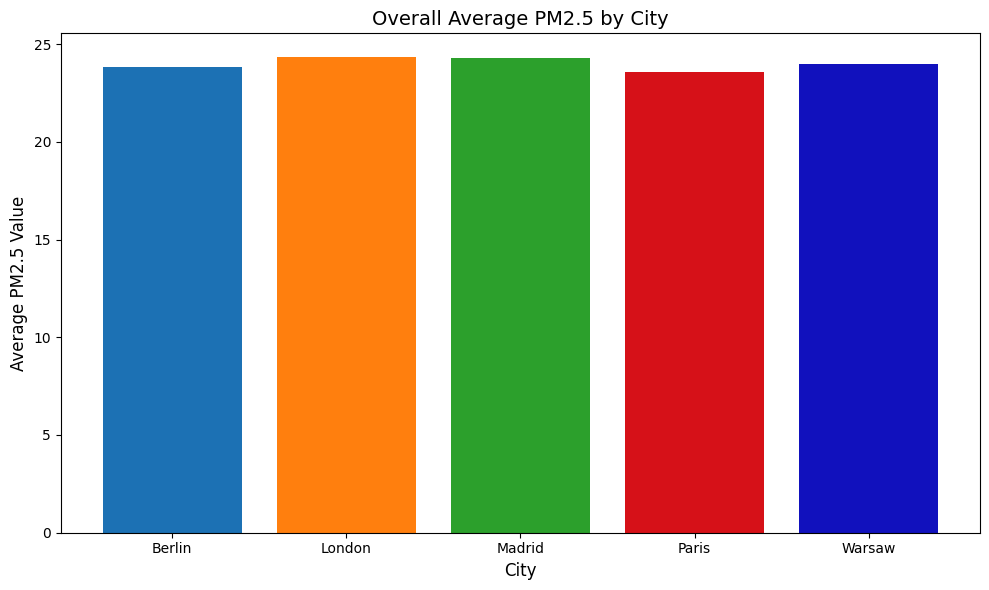

In [24]:
# A bar chart is the best way to compare categorical means.
# It clearly shows that London and Madrid are leading in average pollution levels.
plt.figure(figsize=(10, 6))

plt.bar(avg_pm25.index, avg_pm25.values, color=['#1c71b4', '#ff7f0e', '#2ca02c', '#d61118', '#1111bd'])
plt.title('Overall Average PM2.5 by City', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Average PM2.5 Value', fontsize=12)
plt.tight_layout()

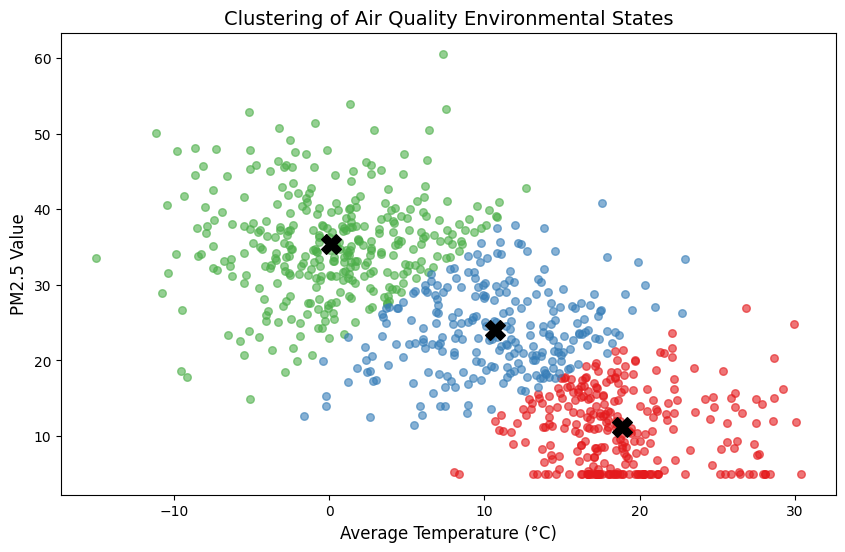

In [25]:
# I added K-Means Clustering as an additional visualization to explore the relationship
# between temperature and pollution. It reveals distinct 'environmental states'.
df_clean = df_clean.dropna(subset=['avg_temp_c', 'pm25']).copy()
X = df_clean[['avg_temp_c', 'pm25']]
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
colors = ['#e41a1c', '#4daf4a', '#377eb8']
labels = ['Moderate States', 'Cold/High Pollution', 'Warm/Low Pollution']

for i in range(3):
    cluster_data = df_clean[df_clean['cluster'] == i]
    plt.scatter(cluster_data['avg_temp_c'], cluster_data['pm25'],
                color=colors[i], label=labels[i], alpha=0.6, s=30)

# Add cluster centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')

plt.title('Clustering of Air Quality Environmental States', fontsize=14)
plt.xlabel('Average Temperature (°C)', fontsize=12)
plt.ylabel('PM2.5 Value', fontsize=12)

plt.show()

## Part E: Interpretation Questions (TODOs)

Write short answers here:

1. Which city shows the most persistent high pm25 levels, and what evidence supports that?
2. How does missing or invalid data affect your confidence in the results?
3. Does temperature appear related to pm25 in your analysis? Explain briefly.
4. What is one limitation of using daily averages for air-quality policy decisions?
5. If you had one more dataset to improve this analysis, what would it be and why?

1.  **London** shows the most persistent high PM2.5 levels. The evidence is found in the overall average bar chart (where it is the highest) and the monthly line plot, which shows London consistently near the top of the pollution scale, especially during the colder months.

2. Missing data introduces uncertainty. While I used **linear interpolation** to estimate these values based on surrounding days, these are still mathematical guesses. For a city like Berlin (nearly 8% missing data), our confidence in the precise peak values is lower than for London (~3% missing).

3.  Yes, there is a clear **inverse relationship**. Both the monthly line plot and the K-Means clustering scatter plot show that PM2.5 levels are significantly higher when temperatures are low (Jan-Feb).

4.   Daily averages **mask short-term spikes**. A city might experience dangerous pollution levels for 3-4 hours during peak traffic, which is critical for people with asthma, but the 'daily average' might still look acceptable.

5. I would add Land Use and Zoning Data: Identifying the proximity of residential areas to industrial zones or construction sites helps determine the "human cost" and the specific type of pollutant (e.g., industrial chemicals vs. construction dust).